In [1]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Артем\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Артем\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Артем\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Артем\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [7]:
df = pd.read_csv('data/emails.csv')

In [8]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [9]:
def get_punct_percent(text):
    count = 0
    for char in text:
        if char in string.punctuation:
            count += 1
            
    return count / len(text) * 100 

In [10]:
def get_caps_ratio(text):    
    count = 0 
    for char in text:
        if char.isupper(): 
            count += 1
            
    return count / len(text) * 100

In [11]:
def get_digit_percent(text):
    count = 0 
    for char in text:
        if char.isdigit(): 
            count += 1
            
    return count / len(text) * 100 

In [12]:
df['length'] = df['text'].apply(len) # Рассчёт длины каждого сообщения
df['punct_percent'] = df['text'].apply(get_punct_percent) # Процент знаков препинания
df['caps_ratio'] = df['text'].apply(get_caps_ratio) # Расчёт доли заглавных букв
df['digit_percent'] = df['text'].apply(get_digit_percent) # Расчёт процента цифр в тексте

In [13]:
df

,text,spam,length,punct_percent,caps_ratio,digit_percent
0,Subject: naturally irresistible your corporate...,1,1484,9.164420,0.067385,0.202156
1,Subject: the stock trading gunslinger fanny i...,1,598,0.167224,0.167224,0.000000
2,Subject: unbelievable new homes made easy im ...,1,448,1.785714,0.223214,2.232143
3,Subject: 4 color printing special request add...,1,500,5.000000,0.200000,6.000000
4,"Subject: do not have money , get software cds ...",1,235,5.531915,0.425532,0.000000
...,...,...,...,...,...,...
5723,Subject: re : research and development charges...,0,1189,9.503785,0.084104,5.887300
5724,"Subject: re : receipts from visit jim , than...",0,1167,6.083976,0.085690,4.798629
5725,Subject: re : enron case study update wow ! a...,0,2131,8.305960,0.046926,4.598780
5726,"Subject: re : interest david , please , call...",0,1060,10.660377,0.094340,5.943396


In [14]:
print(df['spam'].value_counts())

spam
0    4360
1    1368
Name: count, dtype: int64


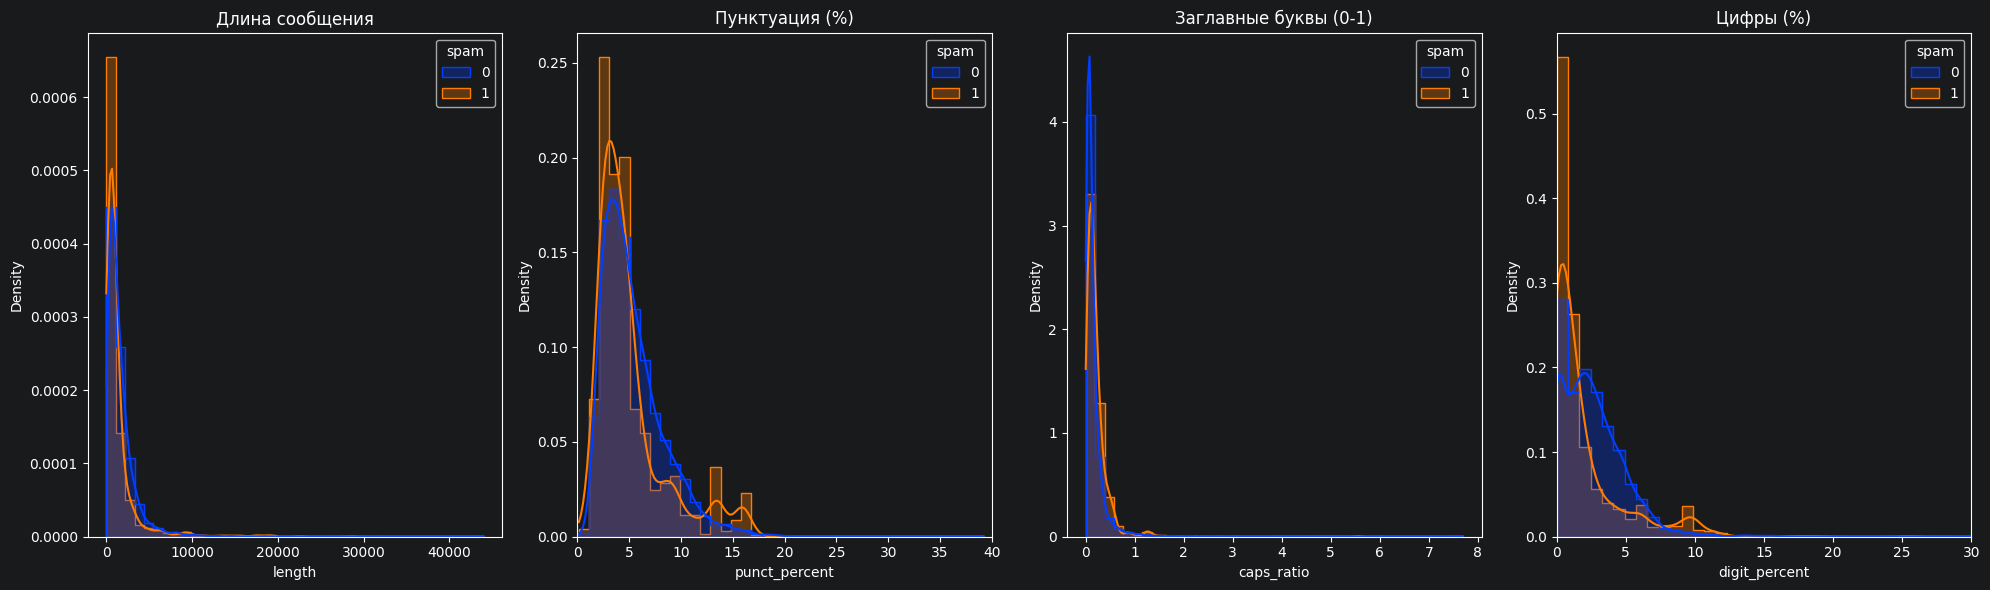

In [15]:
plt.figure(figsize=(20, 6))

kwargs = dict(bins=40, kde=True, stat='density', common_norm=False, palette='bright', element="step", alpha=0.3)

plt.subplot(1, 4, 1)
sns.histplot(data=df, x='length', hue='spam', **kwargs)
plt.title('Длина сообщения')

plt.subplot(1, 4, 2)
sns.histplot(data=df, x='punct_percent', hue='spam', **kwargs)
plt.xlim(0, 40)
plt.title('Пунктуация (%)')

plt.subplot(1, 4, 3)
sns.histplot(data=df, x='caps_ratio', hue='spam', **kwargs)
plt.title('Заглавные буквы (0-1)')

plt.subplot(1, 4, 4)
sns.histplot(data=df, x='digit_percent', hue='spam', **kwargs)
plt.xlim(0, 30)
plt.title('Цифры (%)')

plt.tight_layout()
plt.show()

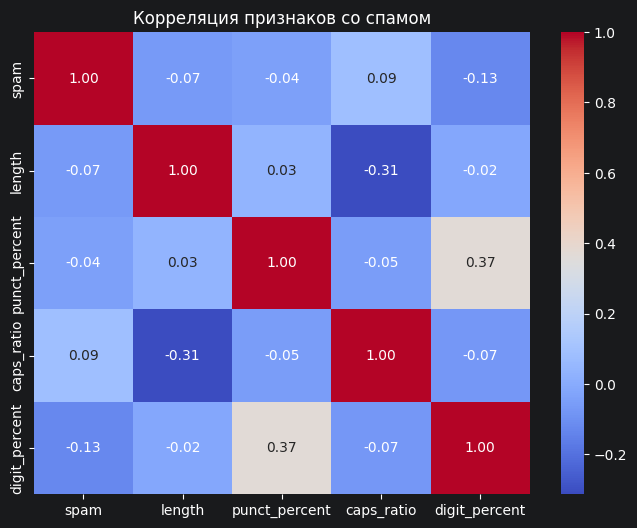

In [16]:
numeric_cols = df[['spam', 'length', 'punct_percent', 'caps_ratio', 'digit_percent']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков со спамом')
plt.show()

In [17]:
def get_spam_word_count(text):
    trigger_words = [
        'free', 'win', 'winner', 'claim', 'prize', 'urgent', 'cash', 'bonus', 
        'congratulations', 'money', 'offer', 'subscribe', 'stop', 'reply', 
        'gift', 'service', 'promotion', 'apply', 'contact', '$', '%', 'now',
        'enjoy', 'hours', 'dollar', 'dollars', 'cost', 'save', 'income',
        'click', 'here'
    ]
    count = 0
    words = str(text).lower().split()
    for word in words:
        clean_word = word.strip('.,!?:;()[]"\'')
        if clean_word in trigger_words:
            count += 1
    return count

In [18]:
def get_phone_count(text):
    phones = re.findall(r'\d{7,11}', str(text))
    return len(phones)

In [19]:
def get_url_count(text):
    text = str(text).lower()
    markers = ['http', 'https', 'www', '.com', '.ru', '.net', '.org']
    count = 0
    for marker in markers:
        count += text.count(marker)
    return count

In [20]:
df['spam_words'] = df['text'].apply(get_spam_word_count)
df['phone_count'] = df['text'].apply(get_phone_count)
df['url_count'] = df['text'].apply(get_url_count)

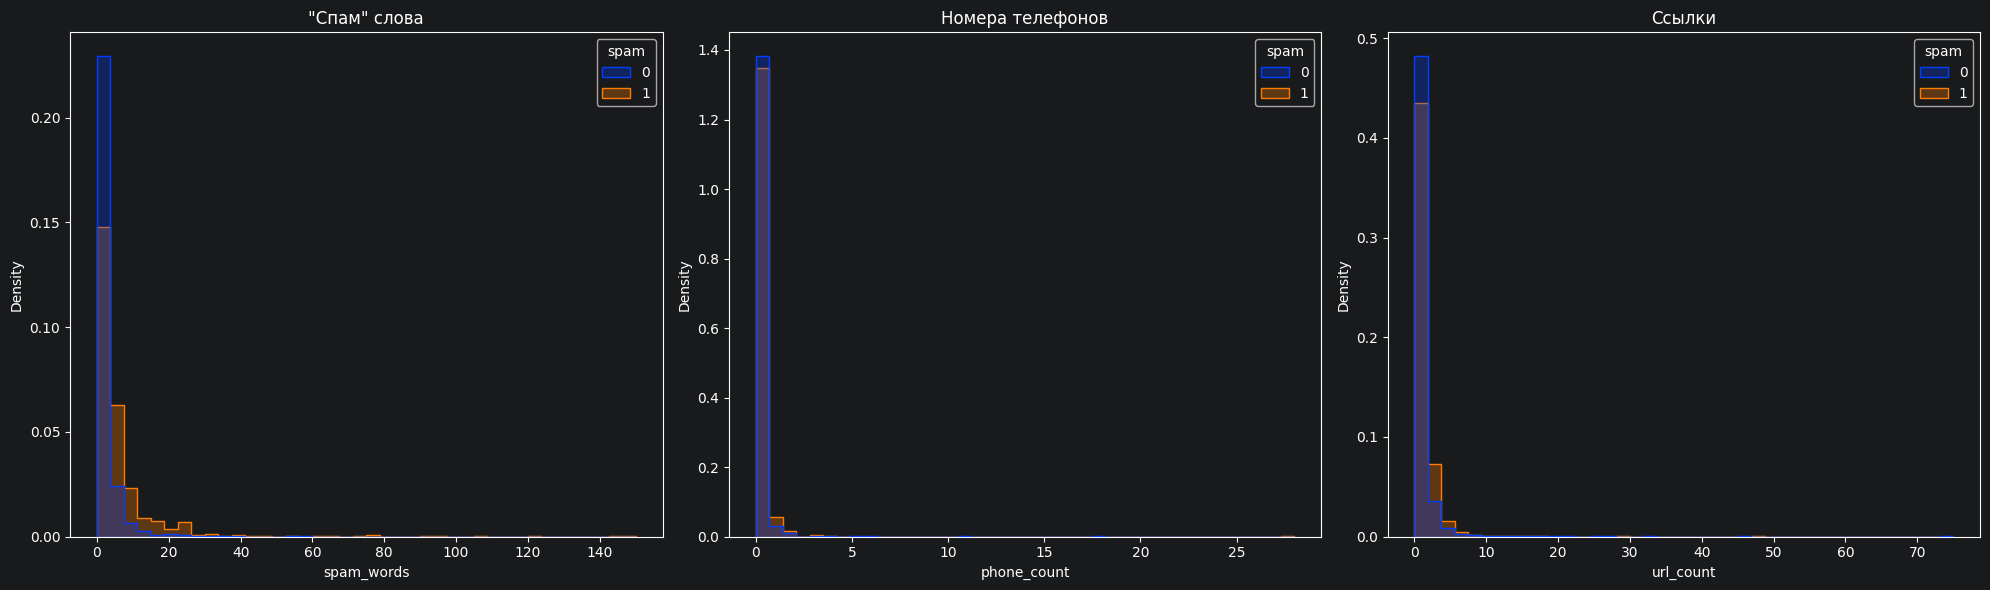

In [21]:
plt.figure(figsize=(20, 6))

kwargs = dict(bins=40, stat='density', common_norm=False, palette='bright', element="step", alpha=0.3)

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='spam_words', hue='spam', **kwargs)
plt.title('"Спам" слова')

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='phone_count', hue='spam', **kwargs)
plt.title('Номера телефонов')

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='url_count', hue='spam', **kwargs)
plt.title('Ссылки')

plt.tight_layout()
plt.show()

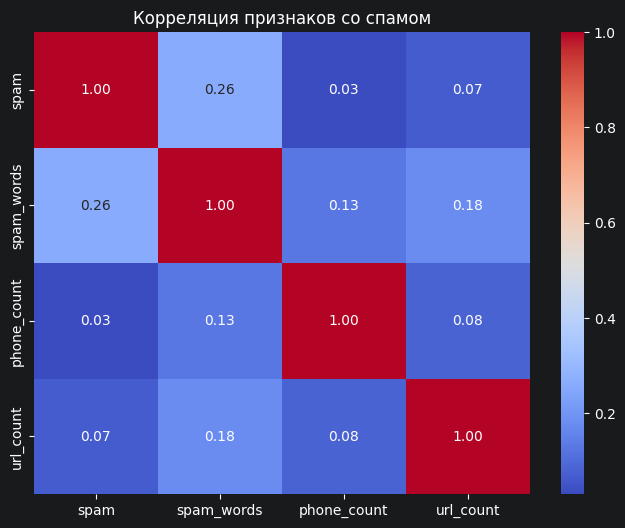

In [22]:
numeric_cols = df[['spam', 'spam_words', 'phone_count', 'url_count']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков со спамом')
plt.show()

In [23]:
lemmatizer = WordNetLemmatizer() 
stop_words = set(stopwords.words('english')) 

In [24]:
def clean_text(text):
    
    text = text.lower() 
    
    text_no_punct = ""
    for char in text:
        if char not in string.punctuation:
            text_no_punct += char

    tokens = text_no_punct.split() 
    
    clean_tokens = [] 
    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma) 
    
    return " ".join(clean_tokens) 

In [25]:
df['clean_text'] = df['text'].apply(clean_text)

In [26]:
print("ИСХОДНЫЙ:", df['text'].iloc[0])
print("ОЧИЩЕННЫЙ:", df['clean_text'].iloc[0]) 

ИСХОДНЫЙ: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability :

In [27]:
X = df['clean_text'] 
y = df['spam']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,     
    random_state=42,   
    stratify=y        
)

In [29]:
tfidf_vect = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf_vect.fit_transform(X_train) 
X_test_tfidf = tfidf_vect.transform(X_test) 

In [30]:
print(f"Размерность матрицы Train: {X_train_tfidf.shape}")
print(f"Размерность матрицы Test:  {X_test_tfidf.shape}")

Размерность матрицы Train: (4582, 3000)
Размерность матрицы Test:  (1146, 3000)


In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train) 
y_pred_rf = rf_model.predict(X_test_tfidf)
print("Random Forest обучен.")

Random Forest обучен.


In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.97      0.96      0.97       274

    accuracy                           0.98      1146
   macro avg       0.98      0.98      0.98      1146
weighted avg       0.98      0.98      0.98      1146



In [33]:
y_pred_train = rf_model.predict(X_train_tfidf) 
f1_train = f1_score(y_train, y_pred_train, pos_label=1) 
f1_test = f1_score(y_test, y_pred_rf, pos_label=1)

In [34]:
print(f"F1-score на обучении (Train): {f1_train:.4f}")
print(f"F1-score на тесте    (Test):  {f1_test:.4f}")

F1-score на обучении (Train): 0.9995
F1-score на тесте    (Test):  0.9651


In [35]:
MAX_WORDS = 2000 
MAX_LEN = 150   

In [36]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'], df['spam'],                              
    test_size=0.2, random_state=42, stratify=df['spam'] 
)

In [37]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>") 
tokenizer.fit_on_texts(X_train_raw)                           

In [38]:
sequences_train = tokenizer.texts_to_sequences(X_train_raw) 
sequences_test = tokenizer.texts_to_sequences(X_test_raw)

In [39]:
X_train_seq = pad_sequences(sequences_train, maxlen=MAX_LEN, padding='pre', truncating='post')
X_test_seq = pad_sequences(sequences_test, maxlen=MAX_LEN, padding='pre', truncating='post')

In [40]:
print(f"Пример текста:\n{X_train_raw.iloc[0]}")
print(f"\nПример последовательности:\n{X_train_seq[0]}")
print(f"\nРазмерность входа для сети: {X_train_seq.shape}")

Пример текста:
Subject: re : a personal favor  anurag ,  i shall talk about vikas to our it people .  can you send me his resume ?  vince  " saksena , anurag " on 05 / 07 / 2001 10 : 06 : 54 am  to : " ' vkamins @ ect . enron . com ' "  cc :  subject : a personal favor  vince ,  i have left a voice mail to you and will wait to talk to you personally . my brother vikas , who is now in london , is trying to make a switch from consulting world to working for a specific firm . over last few months , i have heard of great deal about the success of enron on line business which fits well in the area of his expertise . i am wondering if you know of some one in london who he can speak to regarding career opportunities .  since i spoke to you last , a number of things have changed . recently , my manadate was broaden to include leading a charge for developing a risk management function for both the domestic and international businesses for gmac . needless to say , this is exciting albeit making 

In [41]:
model = Sequential()
model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN)) 
model.add(SpatialDropout1D(0.3)) 
model.add(LSTM(32, dropout=0.4, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid')) 
model.compile(loss='binary_crossentropy', 
              optimizer=Adam(learning_rate=0.0005), 
              metrics=['accuracy']) 
model.summary()

C:\JupyterProject\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop = EarlyStopping(
    monitor='val_loss',     
    patience=2,             
    restore_best_weights=True
)

In [43]:
history = model.fit(
    X_train_seq, y_train,     
    epochs=10,                
    batch_size=64,           
    validation_split=0.1,     
    callbacks=[early_stop],  
    verbose=1                
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7558 - loss: 0.6006 - val_accuracy: 0.7342 - val_loss: 0.5103
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8685 - loss: 0.3254 - val_accuracy: 0.9412 - val_loss: 0.2126
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9479 - loss: 0.1785 - val_accuracy: 0.9608 - val_loss: 0.1398
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9593 - loss: 0.1515 - val_accuracy: 0.9739 - val_loss: 0.1157
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9687 - loss: 0.1199 - val_accuracy: 0.9695 - val_loss: 0.0962
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9728 - loss: 0.0955 - val_accuracy: 0.9586 - val_loss: 0.1223
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9745 - loss: 0.0855 - val_accuracy: 0.9782 - val_loss: 0.0850
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9804 - loss: 0.0700 - val_accuracy: 0.9804 - v

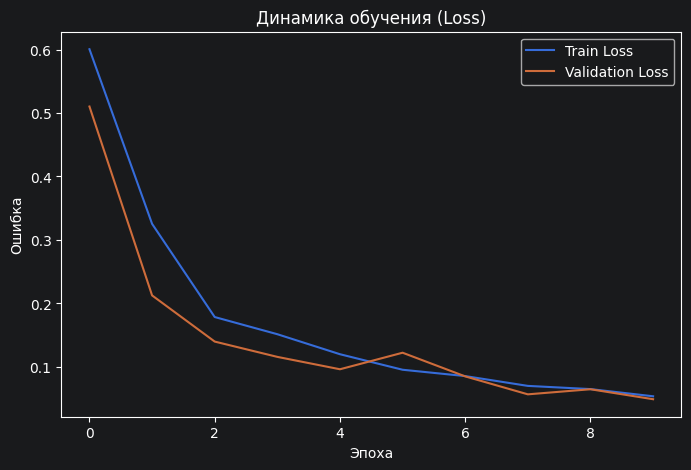

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Динамика обучения (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

In [45]:
y_pred_dl_prob = model.predict(X_test_seq)
y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [46]:
print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       872
           1       0.93      0.97      0.95       274

    accuracy                           0.97      1146
   macro avg       0.96      0.97      0.97      1146
weighted avg       0.98      0.97      0.97      1146

